<a href="https://colab.research.google.com/github/Carrinson/collab-files/blob/main/MA_on_bitcoin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("/content/2024_2026_bitcoin.csv")

df.head()

,Timestamp,Open,High,Low,Close,Volume
0,2024-01-01 00:00:00,42652.0,42655.0,42651.0,42651.0,0.014804
1,2024-01-01 00:01:00,42626.0,42626.0,42620.0,42620.0,0.208011
2,2024-01-01 00:02:00,42616.0,42629.0,42616.0,42629.0,0.029365
3,2024-01-01 00:03:00,42639.0,42642.0,42634.0,42642.0,0.016249
4,2024-01-01 00:04:00,42661.0,42671.0,42655.0,42671.0,0.012124


In [9]:
df.columns = [col.lower() for col in df.columns]

In [10]:
df['close'].isna().sum()

np.int64(1)

In [11]:
df.dropna(inplace=True)

In [16]:
CLOSE = df['close']
NUCLOSE = CLOSE.iloc[296772:296792]

In [21]:
print(CLOSE)

0         42651.0
1         42620.0
2         42629.0
3         42642.0
4         42671.0
           ...   
296788    65562.0
296789    65533.0
296790    65516.0
296791    65505.0
296792    65428.0
Name: close, Length: 296793, dtype: float64


In [17]:
NUCLOSE.head()

,close
296772,65472.0
296773,65521.0
296774,65450.0
296775,65481.0
296776,65510.0


In [18]:
NUCLOSE.tail()

,close
296787,65584.0
296788,65562.0
296789,65533.0
296790,65516.0
296791,65505.0


In [19]:
print(NUCLOSE)

296772    65472.0
296773    65521.0
296774    65450.0
296775    65481.0
296776    65510.0
296777    65495.0
296778    65556.0
296779    65539.0
296780    65570.0
296781    65503.0
296782    65544.0
296783    65602.0
296784    65584.0
296785    65558.0
296786    65543.0
296787    65584.0
296788    65562.0
296789    65533.0
296790    65516.0
296791    65505.0
Name: close, dtype: float64


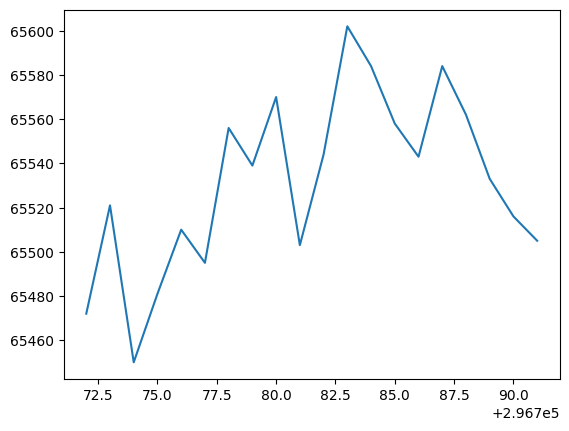

In [22]:
plt.plot(NUCLOSE)

In [23]:
from statsmodels.tsa.stattools import adfuller


In [24]:
price_test_stationary = adfuller(NUCLOSE)

print(f"The value is {price_test_stationary[0]}")
print(f"the p value {price_test_stationary[1]}")

The value is 0.28459324078876924
the p value 0.9766264863839811


In [27]:
log_returns = np.log(NUCLOSE / NUCLOSE.shift(1))

In [28]:
log_returns.isna().sum()


np.int64(1)

In [29]:
log_returns.dropna(inplace=True)



In [30]:
print(log_returns)


296773    0.000748
296774   -0.001084
296775    0.000474
296776    0.000443
296777   -0.000229
296778    0.000931
296779   -0.000259
296780    0.000473
296781   -0.001022
296782    0.000626
296783    0.000885
296784   -0.000274
296785   -0.000397
296786   -0.000229
296787    0.000625
296788   -0.000336
296789   -0.000442
296790   -0.000259
296791   -0.000168
Name: close, dtype: float64


In [32]:
data2 = log_returns

log_returns_test_stationary = adfuller(data2)

In [33]:

print(f"The value is {log_returns_test_stationary[0]}")
print(f"the p value {log_returns_test_stationary[1]}")

The value is 1.6978347760552837
the p value 0.9981233216340624


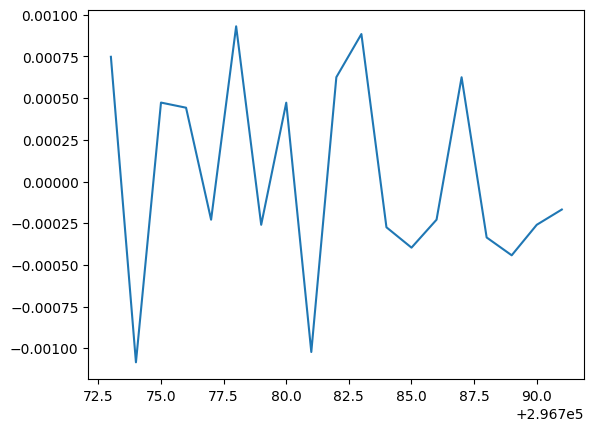

In [34]:
df2 = pd.DataFrame(data2)

plt.plot(df2)